# RAG Evaluation Framework — Demo

A **provider-agnostic RAG evaluation framework** benchmarked on HotpotQA.  
Supports any OpenAI-compatible endpoint (OpenAI, Azure OpenAI, Ollama, Groq, Together AI, etc.).

All heavy implementation lives in `src/` — this notebook shows only high-level orchestration:
settings → load → build → evaluate → visualize → report.

---

**13 metrics:** Exact Match, F1, Contains, Hit Rate, Groundedness, Context Coverage,
Completeness (cascade), Faithfulness (RAGAS), Answer Relevancy, Context Relevancy,
Conciseness, Relevance SNR, Quality Score.

**4 prompt variants:** Baseline · Concise · Detailed · Citation

---
## Before You Run — Choose Your Setup Path

| | Google Colab | Local (Jupyter) |
|---|---|---|
| **Credentials** | Colab Secrets manager (key icon, left sidebar) | `.env` file (copy `.env.example → .env`) |
| **Data** | Upload `hotpot_train_v1.1.json` to Google Drive | Place in `./data/` |
| **Download data** | [hotpotqa.github.io](https://hotpotqa.github.io/) → Training set v1.1 | Same |

**Required secrets / env vars:**
```
OPENAI_API_KEY          your API key
OPENAI_BASE_URL         https://api.openai.com/v1  (or your provider's URL)
OPENAI_GENERATION_MODEL gpt-4o
OPENAI_EMBEDDING_MODEL  text-embedding-3-small
EMBEDDING_CHOICE        small  (or: large | local)
HOTPOTQA_DATA_PATH      ./data/hotpot_train_v1.1.json
```

For **Azure OpenAI**, also set `OPENAI_API_VERSION` (e.g. `2025-04-01-preview`).

---
# 📦 CELL 1: Install Required Packages

Installs all dependencies. **Run once per environment.**

- `rank-bm25` — keyword search for hybrid retrieval
- `sentence-transformers` — local embeddings (free, no API key needed)
- `openai`, `python-dotenv`, `rouge-score`, `scikit-learn`, `matplotlib`, `seaborn`

In [1]:
# =============================================================================
# CELL 1: PACKAGE INSTALLATION
# =============================================================================

import sys
print("Installing required packages...")
print("This will take 2-3 minutes on first run...\n")

!pip install -q openai>=1.0.0 pandas numpy scikit-learn
!pip install -q sentence-transformers nltk rouge-score rank-bm25
!pip install -q matplotlib seaborn scipy
!pip install -q tqdm python-dotenv python-dateutil

import nltk
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)

print("\n✓ All packages installed and NLTK data downloaded")

Installing required packages...
This will take 2-3 minutes on first run...

zsh:1: 1.0.0 not found

✓ All packages installed and NLTK data downloaded


---
# 📚 CELL 2: Environment & Imports

Detects whether you are running in **Google Colab** or **locally**, then loads
credentials from the right source (Colab Secrets or `.env` file).

All framework logic lives in `src/` — browse those files for implementation details.

In [2]:
# =============================================================================
# CELL 2: IMPORTS & ENVIRONMENT SETUP
# =============================================================================

# -- macOS: filter MallocStackLogging noise from OS-level stderr --------------
# This message is printed by the macOS C runtime directly to fd 2 (bypassing
# Python's sys.stderr), so warnings filters can't catch it.  A background
# thread intercepts fd 2 and drops any line containing "MallocStackLogging".
import sys as _sys, os as _os
if _sys.platform == 'darwin':
    import threading as _threading
    _pipe_r, _pipe_w = _os.pipe()
    _real_stderr_fd = _os.dup(2)
    _os.dup2(_pipe_w, 2)
    _os.close(_pipe_w)

    def _stderr_filter_thread():
        _buf = b''
        while True:
            try:
                _chunk = _os.read(_pipe_r, 4096)
            except OSError:
                break
            if not _chunk:
                break
            _buf += _chunk
            while b'\n' in _buf:
                _line, _buf = _buf.split(b'\n', 1)
                if b'MallocStackLogging' not in _line:
                    _os.write(_real_stderr_fd, _line + b'\n')
        if _buf and b'MallocStackLogging' not in _buf:
            _os.write(_real_stderr_fd, _buf)
        _os.close(_pipe_r)

    _t = _threading.Thread(target=_stderr_filter_thread, daemon=True)
    _t.start()
# -----------------------------------------------------------------------------

import json, os, sys, gc, time, random
from pathlib import Path

import numpy as np
import pandas as pd

# --- Environment detection (Colab vs local) ---
try:
    from google.colab import userdata, drive  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
    def _secret(key, default=''):
        try: return userdata.get(key) or default
        except: return default
    for k, d in [
        ('OPENAI_API_KEY',          ''),
        ('OPENAI_BASE_URL',         'https://api.openai.com/v1'),
        ('OPENAI_API_VERSION',      ''),
        ('OPENAI_GENERATION_MODEL', 'gpt-4o'),
        ('OPENAI_EMBEDDING_MODEL',  'text-embedding-3-small'),
        ('EMBEDDING_CHOICE',        'small'),
        ('HOTPOTQA_DATA_PATH',      '/content/drive/MyDrive/data/hotpot_train_v1.1.json'),
    ]:
        os.environ.setdefault(k, _secret(k, d))
    REPO_ROOT      = Path('/content/llm-eval-framework')
    CHECKPOINT_DIR = '/content/checkpoints'
    OUTPUT_DIR     = '/content/outputs'
    REPORTS_DIR   = '/content/reports'
else:
    from dotenv import load_dotenv
    load_dotenv()
    NOTEBOOK_DIR   = Path().resolve()
    REPO_ROOT      = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
    CHECKPOINT_DIR = str(REPO_ROOT / 'checkpoints')
    OUTPUT_DIR     = str(REPO_ROOT / 'outputs')
    REPORTS_DIR   = str(REPO_ROOT / 'reports')

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(REPORTS_DIR, exist_ok=True)
os.chdir(REPO_ROOT)

# Make src/ importable
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

# --- Framework imports ---
from src.config             import Config
from src.metrics            import EvalMetrics
from src.vector_store       import VectorStore
from src.rag_system         import EnhancedRAGSystem
from src.cost_tracker       import CostTracker
from src.quality_guard      import QualityGuard
from src.investigator       import LowQualityInvestigator
from src.data_loader        import load_hotpotqa, sample_questions
from src.preflight          import run_preflight_check
from src.evaluation_runner  import run_evaluation
from src.visualizer         import generate_dashboard
from src.report_generator   import generate_report

print(f"✓ Running {'in Google Colab' if IN_COLAB else 'locally'}")
print(f"  Repo root  : {REPO_ROOT}")
print(f"  Output dir : {OUTPUT_DIR}")
print(f"  Reports dir: {REPORTS_DIR}")
print(f"  Checkpoints: {CHECKPOINT_DIR}")
print("\n✓ All framework modules loaded")

✓ Running locally
  Repo root  : /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework
  Output dir : /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework/outputs
  Reports dir: /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework/reports
  Checkpoints: /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework/checkpoints

✓ All framework modules loaded


---
# ⚙️ CELL 3: Settings

Adjust these before running. Everything else (model names, embedding dimensions,
prompt templates, metric weights) is pre-configured in `src/config.py`.

| Variant | Intent | Best for |
|---------|--------|----------|
| `baseline` | Natural, unguided | Benchmarking LLM defaults |
| `concise` | Precision-first, minimal tokens | APIs, cost-sensitive apps |
| `detailed` | Comprehensive, self-contained | Support, education |
| `citation` | Attribution-enforced | Legal, medical, finance |

**Key design choices:**
- Temperature **0.2** — biggest single driver of F1 and faithfulness on HotpotQA
- Top-K **20** — multi-hop questions need evidence from 2+ documents
- Hybrid retrieval **60/40** — BM25 catches entity names that embeddings miss
- Completeness **cascade** — LLM judge fires on ~20% of answers where embeddings are unreliable

In [3]:
# =============================================================================
# CELL 3: SETTINGS — adjust these before running
# =============================================================================

# ── Evaluation scope ─────────────────────────────────────────────────────────
Config.NUM_EVAL_QUESTIONS    = 100    # start small (10-50), scale to 2000
Config.RANDOM_SEED           = 42

# ── What to run ──────────────────────────────────────────────────────────────
Config.RUN_PROMPT_COMPARISON    = True   # evaluate all 4 prompt variants
Config.RUN_BASELINE_TEST        = True   # no-context baseline
Config.RUN_CORRELATION_ANALYSIS = True   # context quality vs answer quality

# ── Checkpointing ─────────────────────────────────────────────────────────────
Config.FORCE_RESTART              = False  # True → ignore eval checkpoint, start fresh
Config.FORCE_REBUILD_VECTOR_STORE = False  # True → rebuild vector store from scratch

# ── Quality gate thresholds (for flagging, not filtering) ────────────────────
Config.MIN_GROUNDEDNESS = 0.5
Config.MIN_COMPLETENESS = 0.4

print("✓ Settings configured")
print(f"  Questions  : {Config.NUM_EVAL_QUESTIONS}")
print(f"  Provider   : {'Azure OpenAI' if Config.API_VERSION else 'OpenAI-compatible'}")
print(f"  Embedding  : {Config.EMBEDDING_CHOICE} → {Config.EMBEDDING_MODEL}")
print(f"  Data path  : {Config.DATA_FILE_PATH}")
print(f"  Output dir : {OUTPUT_DIR}")
print(f"  Reports dir: {REPORTS_DIR}")

✓ Settings configured
  Questions  : 100
  Provider   : Azure OpenAI
  Embedding  : small → text-embedding-3-small
  Data path  : data/hotpot_train_v1.1.json
  Output dir : /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework/outputs
  Reports dir: /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework/reports


---
# 🔌 CELL 4: Initialize LLM Clients

Provider is auto-detected from your `.env` (or Colab Secrets):

| `OPENAI_API_VERSION` | Provider | Client |
|---|---|---|
| Set (e.g. `2025-04-01-preview`) | Azure OpenAI | `AzureOpenAI` |
| Blank | OpenAI / Ollama / Groq / etc. | `OpenAI` |

See `docs/provider-setup.md` for step-by-step setup.

In [4]:
# =============================================================================
# CELL 4: INITIALIZE LLM CLIENTS
# =============================================================================

# Config.create_client() auto-detects Azure OpenAI vs OpenAI-compatible
# from your .env / Colab Secrets (OPENAI_API_VERSION set → Azure, blank → OpenAI)
client            = Config.create_client()
embedding_client  = client
generation_client = client

print(f"✓ Client initialized: {'Azure OpenAI' if Config.API_VERSION else 'OpenAI-compatible'}")
print(f"  Gen model : {Config.GENERATION_MODEL}")
print(f"  Emb model : {Config.EMBEDDING_MODEL}")

✓ Client initialized: Azure OpenAI
  Gen model : gpt-4o
  Emb model : text-embedding-3-small


---
# 📂 CELL 5: Load HotpotQA Data

Loads the HotpotQA dataset and applies **question-centric sampling** — the document
library is built to guarantee every sampled question has its supporting documents
included (no retrieval misses due to missing documents).

> **Resource estimates (API embeddings, `text-embedding-3-small`):**
>
> | Questions | Documents | Build time | Cost |
> |---|---|---|---|
> | 50 | ~5k | ~2 min | <$0.001 |
> | 500 | ~50k | ~45 min | ~$0.001 |
> | 2,000 | ~180k | ~3 hrs | ~$0.004 |
>
> Set `EMBEDDING_CHOICE=local` for free local embeddings (~10% lower quality).

In [5]:
# =============================================================================
# CELL 5: LOAD DATA
# =============================================================================

full_data, document_library = load_hotpotqa(Config.DATA_FILE_PATH)
data = sample_questions(full_data, Config)

print(f"✓ Ready: {len(data):,} questions, {len(document_library):,} documents")

Loading HotpotQA data...
✓ Loaded 90447 questions

Building document library...
✓ Built library with 899,667 documents
  Average document length: 546 chars
DATASET SAMPLING (QUESTION-CENTRIC)

📊 Question-centric sampling
   Target: 100 questions
   Source: 90,447 questions, 899,667 docs

✓ Sampled 100 questions
✓ Sampled questions need 999 unique documents
   Expected: ~1,000 (10 docs/question)
✓ Indexed 899,667 available documents

🔍 Matching titles...
✓ Found 999 / 999 documents (100.0%)

🎯 Filtering questions...
✓ Kept 100 questions with complete context

SAMPLING COMPLETE
  Questions:       100
  Documents:       999
  Docs/Question:   10.0
  Match rate:      100.0%
  Seed:            42

✓ Ready: 100 questions, 899,667 documents


---
# 🏗️ CELL 6: Build Vector Store

Builds **hybrid retrieval** — semantic (dense embeddings) + keyword (BM25) —
with adaptive checkpointing so a long build can be safely interrupted and resumed.

| Strategy | Weight | Strength |
|---|---|---|
| Dense (embedding) | 60% | Semantic similarity, paraphrase matching |
| Sparse (BM25) | 40% | Exact entity names, dates, proper nouns |

> ⚠️ **First run:** 2–45 min depending on dataset size and embedding provider.  
> **Subsequent runs:** loads from cache instantly (`FORCE_REBUILD_VECTOR_STORE = False`).

In [6]:
# =============================================================================
# CELL 6: BUILD VECTOR STORE
# =============================================================================

documents_list    = list(document_library.values())
vector_store_file = os.path.join(CHECKPOINT_DIR, f'vs_{len(documents_list)}_{Config.EMBEDDING_CHOICE}.pkl')
checkpoint_file   = os.path.join(CHECKPOINT_DIR, f'vs_ckpt_{len(documents_list)}_{Config.EMBEDDING_CHOICE}.pkl')

vector_store = VectorStore.load_or_build(
    documents=documents_list,
    embedding_client=embedding_client,
    embedding_model=Config.EMBEDDING_MODEL,
    config=Config,
    vector_store_file=vector_store_file,
    checkpoint_file=checkpoint_file,
)

print(f"✓ Vector store ready: {len(vector_store.documents):,} docs, shape {vector_store.embeddings.shape}")

Found cache: /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework/checkpoints/vs_899667_small.pkl — validating...
Cache valid — loading 899,667 documents
✓ Vector store ready: 899,667 docs, shape (899667, 1536)


---
# 🤖 CELL 7: Initialize RAG System

Instantiates the full pipeline and runs **3 sanity-check questions** to confirm
end-to-end operation before the full evaluation.

**Pipeline:** question → hybrid retrieval (top-20) → LLM generation (temp=0.2) → QualityGuard validation → answer + metrics

---
## 📊 Metrics & Quality Framework Reference

### 13 Evaluation Metrics

| # | Metric | Method | Cost |
|---|--------|--------|------|
| 1 | **Exact Match** | Token normalization | Free |
| 2 | **F1 Score** | Bag-of-words overlap | Free |
| 3 | **Contains Match** | Gold answer substring in prediction | Free |
| 4 | **ROUGE-L** | Longest common subsequence | Free |
| 5 | **Answer Relevance** | cosine_sim(answer, question) | Embedding |
| 6 | **Context Relevance** | cosine_sim(context, question) | Embedding |
| 7 | **Groundedness** | MiniMax avg_i max_j sim(ans_i, ctx_j) | Embedding |
| 8 | **RAGAS Faithfulness** | Atomic claim extraction → LLM entailment | LLM |
| 9 | **Completeness** | 2-tier cascade (embedding + conditional LLM) | Mixed |
| 10 | **Conciseness** | Length penalty vs question length | Free |
| 11 | **Refusal Detection** | Phrase-pattern regex | Free |
| 12 | **SNR** | Ratio of context-grounded tokens | Free |
| 13 | **Quality Score** | Weighted composite | — |

### Completeness Cascade

```
Every answer → Tier 1 Embedding (always runs)
    │
    ├── Trigger B: |completeness − groundedness| > 0.3  OR
    │              |completeness − faithfulness| > 0.3
    ├── Trigger C: short answer + rich context
    │
    └── No trigger → Tier 1 score ($0 extra, ~80% of answers)
        Trigger   → Tier 2 LLM judge (~20% of answers)
```

In [7]:
# =============================================================================
# CELL 7: INITIALIZE RAG SYSTEM
# =============================================================================

sys.setrecursionlimit(50000)
gc.set_threshold(700, 15, 15)

quality_guard = QualityGuard(
    embedding_client=embedding_client,
    embedding_model=Config.EMBEDDING_MODEL,
    config=Config,
)

rag_system = EnhancedRAGSystem(
    vector_store=vector_store,
    generation_client=generation_client,
    quality_guard=quality_guard,
    config=Config,
)
2
print(f"✓ RAG system ready")
print(f"  Temperature : {Config.TEMPERATURE}")
print(f"  Top-K       : {Config.TOP_K}")
print(f"  Retrieval   : {Config.RETRIEVAL_STRATEGY}")

✓ RAG system ready
  Temperature : 0.2
  Top-K       : 20
  Retrieval   : hybrid


---
# ✅ CELL 8: Pre-Flight Check

Validates all 13 framework components before committing to the full evaluation run.
Fix any ❌ before proceeding to Cell 9.

Checks: Data · Vector Store · Generation Client · Quality Guard ·
EvalMetrics (core + cascade) · Completeness Tier 1 & 2 · Cost Tracker ·
Prompt Variants · Cost Estimate · Full Pipeline

In [8]:
# =============================================================================
# CELL 8: PRE-FLIGHT CHECK
# =============================================================================
# Runs 13 validation checks. Fix any ❌ before proceeding.

preflight_ok = run_preflight_check(
    data=data,
    vector_store=vector_store,
    embedding_client=embedding_client,
    generation_client=generation_client,
    config=Config,
)

assert preflight_ok, "Pre-flight check failed — fix ❌ items before running evaluation."

🔍 COMPREHENSIVE PRE-EVALUATION SYSTEM CHECK

Checks: Data | Vector Store | RAG System | Quality Guard |
        Prompts | EvalMetrics | Cost Tracker | NEW: Completeness Cascade

────────────────────────────────────────────────────────────
CHECK 1: Data
────────────────────────────────────────────────────────────
✅ 100 questions loaded
   Sample Q:    Which Emmett's Mark actor also played in the HBO series "The Wire"?...
   Sample A:    John Doman
   Gold docs:   Nathan Barksdale, Pablo Schreiber

────────────────────────────────────────────────────────────
CHECK 2: Vector Store
────────────────────────────────────────────────────────────
✅ Vector store ready
   Documents:   899,667
   Embeddings:  (899667, 1536)
   Model:       text-embedding-3-small
   Strategy:    hybrid
   Client:      ✓ (embedding smoke test passed)

────────────────────────────────────────────────────────────
CHECK 3: Generation Client
────────────────────────────────────────────────────────────
✅ Generation clien

---
# 🚀 CELL 9: Run Evaluation

Runs the **multi-prompt evaluation loop** across all 4 prompt variants.
Progress is checkpointed every `Config.CHECKPOINT_INTERVAL` questions — safe to interrupt and resume.

> **Cost estimate (GPT-4o, API embeddings):**  
> 100 questions ≈ \$0.04 generation + \$0.003 evaluation overhead  
> 2,000 questions ≈ \$0.84 generation + \$0.05 evaluation overhead

Results saved to `outputs/multi_prompt_eval_results_<N>.json`

In [9]:
# =============================================================================
# CELL 9: RUN EVALUATION
# =============================================================================
# Full multi-prompt evaluation with quality validation, cascade completeness,
# cost tracking, checkpointing, sanity checks, and low-quality investigation.

results = run_evaluation(
    rag_system=rag_system,
    data=data,
    embedding_client=embedding_client,
    generation_client=generation_client,
    config=Config,
    output_dir=OUTPUT_DIR,
    checkpoint_dir=CHECKPOINT_DIR,
)

🚀 MULTI-PROMPT EVALUATION
  Questions:   100 × 4 prompts
  Variants:    baseline, concise, detailed, citation

  Quality Validation:      ✅ ENABLED
  Faithfulness method:     RAGAS LLM-as-judge
  Completeness Cascade:    ✅ ENABLED (Tier B + C triggers)
  Cost Tracking:           ✅ ENABLED (generation vs evaluation)

🔄 Starting evaluation...
   Questions remaining: 100
   Checkpoint every:    50 questions



Evaluating:  50%|████████████████████████████████▌                                | 50/100 [2:51:31<3:04:34, 221.49s/it]


✓ 50/100 | 0.3 q/min | ETA: 171min | Gen: $11.79 | Eval: $25.50 | Cascade: 77%


Evaluating: 100%|██████████████████████████████████████████████████████████████████| 100/100 [6:23:30<00:00, 230.11s/it]


✓ 100/100 | 0.3 q/min | ETA: 0min | Gen: $23.28 | Eval: $50.74 | Cascade: 80%

📊 AGGREGATING RESULTS

📊 RESULTS SUMMARY

Variant      | F1≥0.5  | Contains  | Faith  | Ground  | Complete  | Quality  | Refusal  | Length
----------------------------------------------------------------------------------------------------
Baseline     |  82.0% |    73.0% |  0.96 |   0.44 |    0.761 |    0.59 |    0.0% |   2.0w
Concise      |  61.6% |    61.6% |  0.76 |   0.41 |    0.642 |    0.56 |   25.3% |   2.4w
Detailed     |   0.0% |    65.0% |  0.75 |   0.62 |    0.735 |    0.70 |   27.0% |  40.2w
Citation     |  71.4% |    67.3% |  0.85 |   0.43 |    0.713 |    0.57 |   14.3% |   2.2w

────────────────────────────────────────────────────────────
Completeness Cascade (Tier 2 LLM judge):
  Baseline     trigger=100.0%   agreement=27.3%
  Concise      trigger=74.7%    agreement=19.2%
  Detailed     trigger=57.0%    agreement=21.1%
  Citation     trigger=86.7%    agreement=23.5%

Retrieval hit rate:  37.


✓ Checkpoint cleaned up

✅ EVALUATION COMPLETE
  Questions evaluated: 100/100
  Time elapsed:        383.5 minutes
  Errors:              0
  Generation cost:     $23.2833
  Evaluation cost:     $50.7405
  Total cost:          $74.0238
  Results saved:       /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework/outputs/multi_prompt_eval_results_100.json

🔍 EVALUATION RESULTS DIAGNOSTIC

✅ Loaded: /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework/outputs/multi_prompt_eval_results_100.json

📋 Metadata:
   timestamp: 1779587684.331556
   num_questions: 100
   eval_sample_size: 100
   quality_validation: True
   ragas_faithfulness: True
   completeness_cascade: True
   faithfulness_method: RAGAS LLM-as-judge
   completeness_method: Cascade (Tier 1 embedding + Tier 2 LLM)
   variants: ['baseline', 'concise', 'detailed', 'citation']
   top_k: 20
   retrieval_strategy: hybrid
   generation_model: gpt-4o
   embedding_model: text-embedding-3-small
   errors: 0
   total_cost: 74.02383

---
# 📊 CELL 10: Visualizations

Generates **3 publication-quality figures** from the evaluation results:

| Figure | Contents |
|---|---|
| `evaluation_dashboard.png` | 6-panel: F1 accuracy, quality heatmap, faithfulness distribution, refusal & citation rates, cost breakdown |
| `retrieval_analysis.png` | Hit rate distribution + hit rate vs F1 correlation per variant |
| `cost_cascade_analysis.png` | Cost breakdown by component + cascade trigger/agreement rates |

📂 Loading: /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework/outputs/multi_prompt_eval_results_100.json
✅ Loaded 100 questions | Variants: baseline, concise, detailed, citation
   Faithfulness method: RAGAS LLM-as-judge


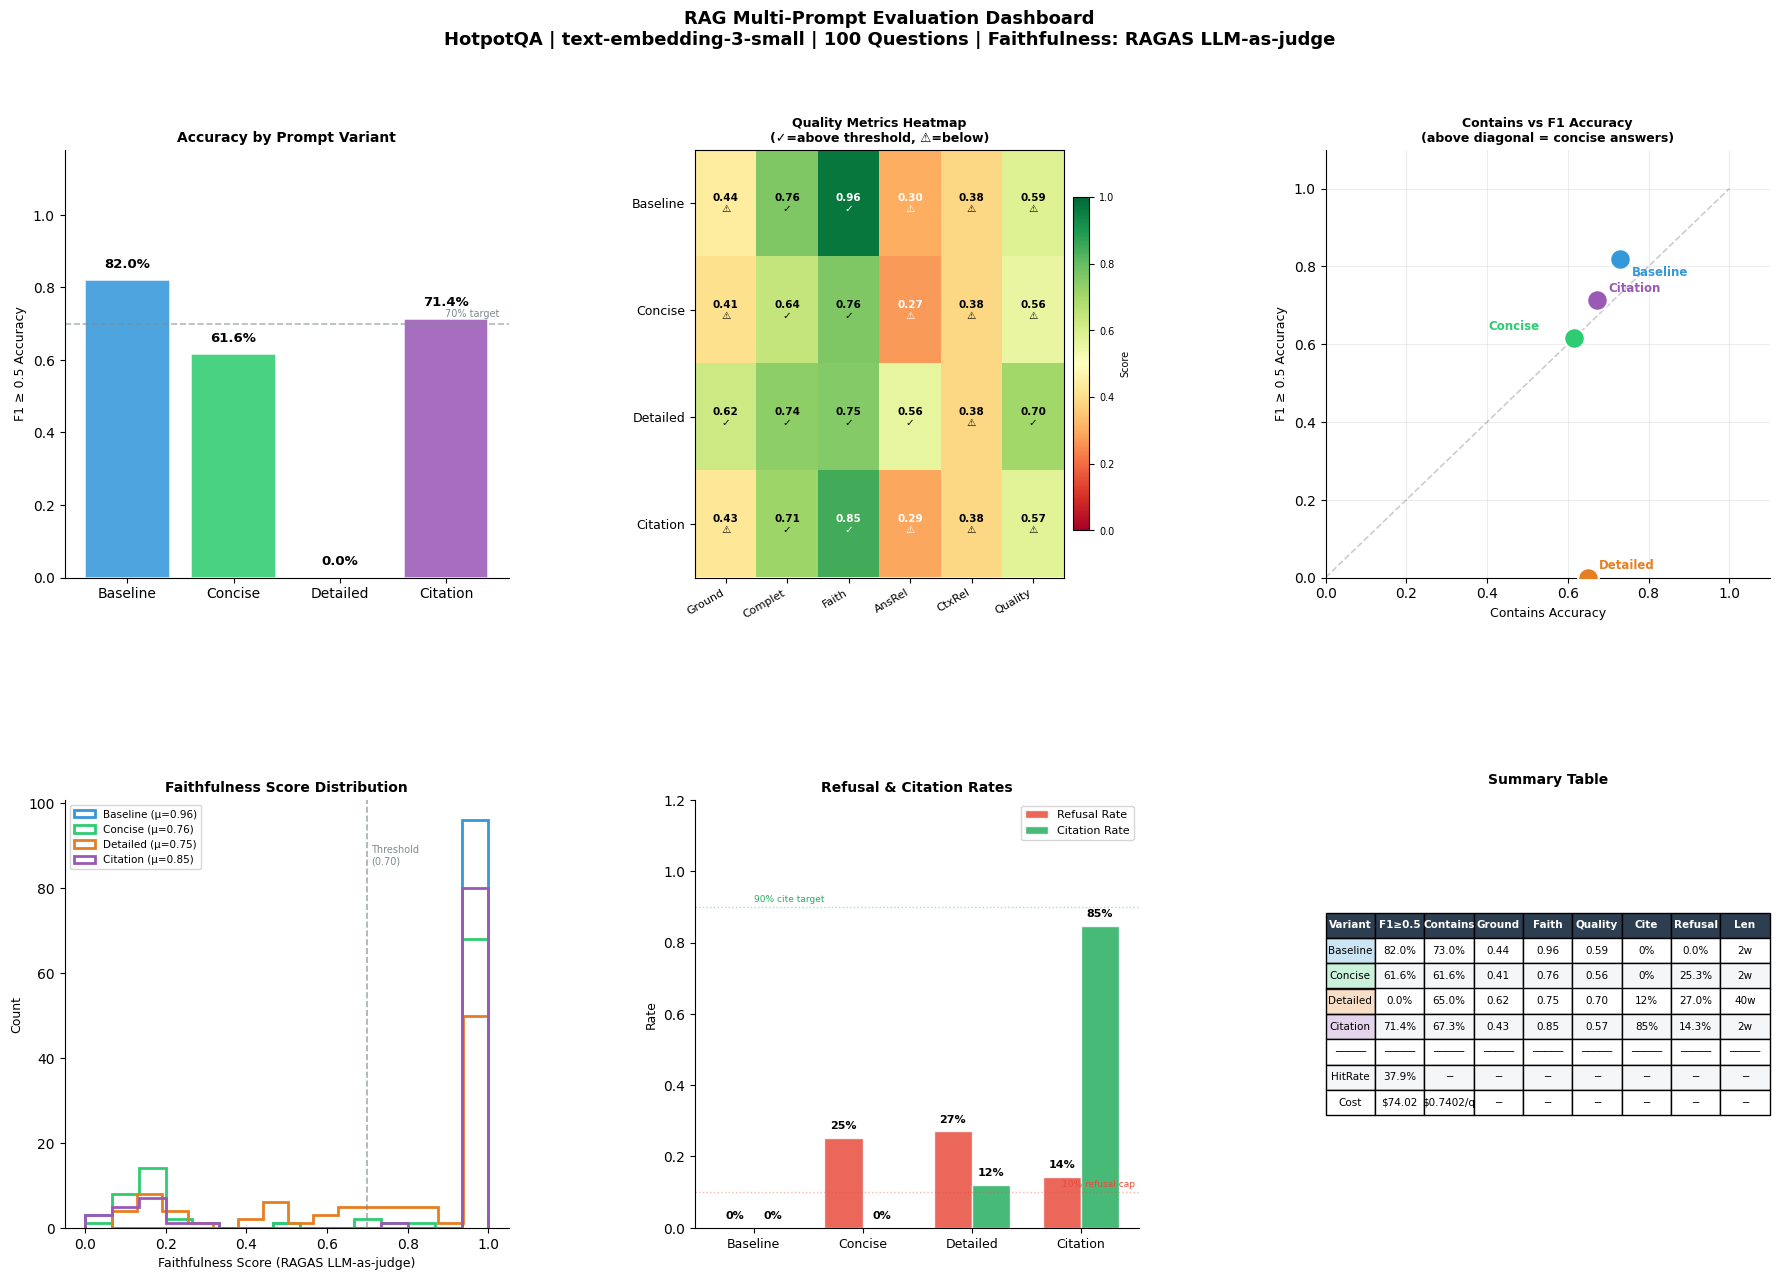

✓ Figure 1 saved: /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework/outputs/evaluation_dashboard.png


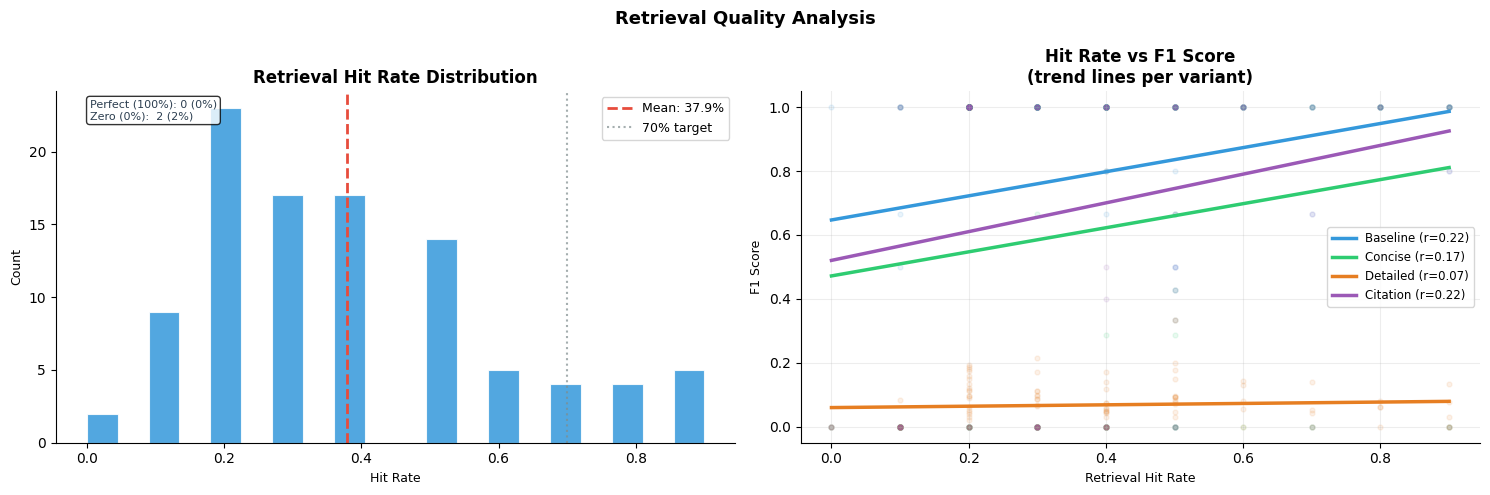

✓ Figure 2 saved: /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework/outputs/retrieval_analysis.png


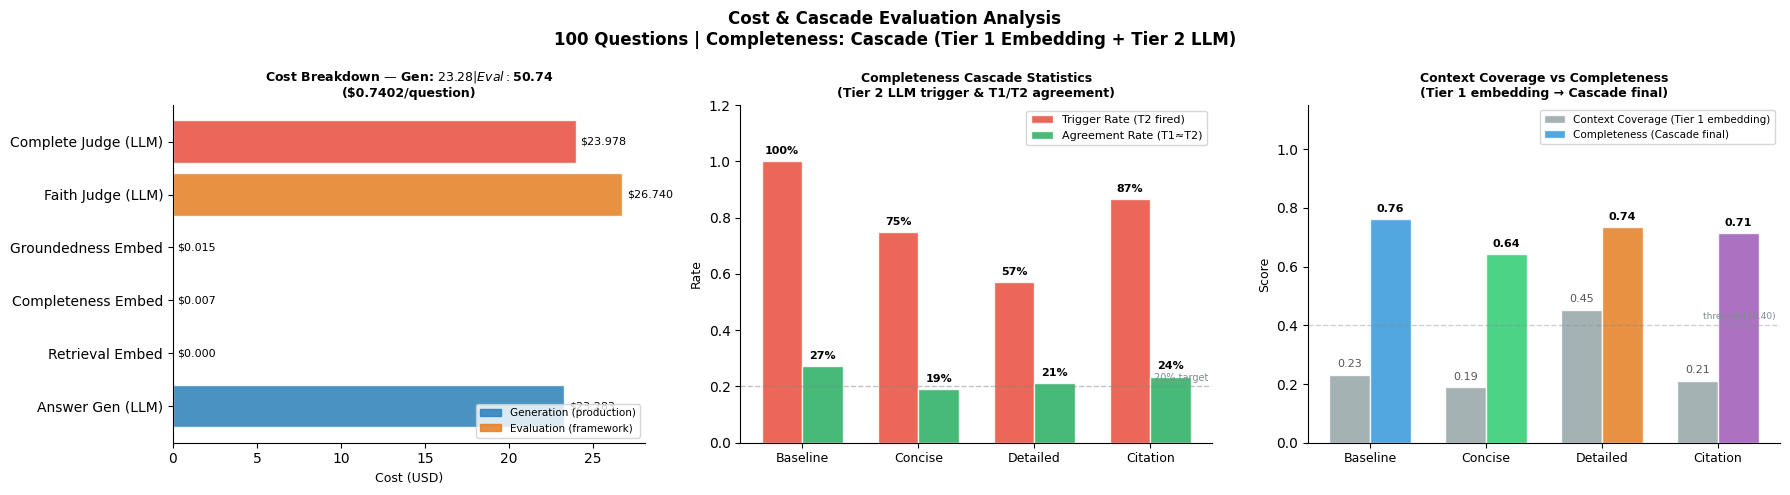

✓ Figure 3 saved: /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework/outputs/cost_cascade_analysis.png

📊 RESULTS SUMMARY

Variant      | F1≥0.5  | Contains  | Faith   | Ground  | Quality  | Refusal  | Length
-------------------------------------------------------------------------------------
Baseline     |  82.0% |    73.0% |   0.96 |   0.44 |    0.59 |    0.0% |   2.0w
Concise      |  61.6% |    61.6% |   0.76 |   0.41 |    0.56 |   25.3% |   2.4w
Detailed     |   0.0% |    65.0% |   0.75 |   0.62 |    0.70 |   27.0% |  40.2w
Citation     |  71.4% |    67.3% |   0.85 |   0.43 |    0.57 |   14.3% |   2.2w

Retrieval hit rate:       37.9%
Questions evaluated:      100
Total cost:               $74.0238
Cost per question:        $0.7402
Faithfulness method:      RAGAS LLM-as-judge
Cascade trigger rate:     79.6%  (target ~20% — ⚠️ elevated)
Cascade agreement rate:   23.1%

  Figures saved:
  1. /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework/outputs/evaluation_dashboard.

In [10]:
# =============================================================================
# CELL 10: VISUALIZE
# =============================================================================
# Generates evaluation_dashboard.png, retrieval_analysis.png,
# and cost_cascade_analysis.png in OUTPUT_DIR.

import glob
results_file = sorted(
    glob.glob(os.path.join(OUTPUT_DIR, 'multi_prompt_eval_results_*.json')),
    key=os.path.getmtime
)[-1]

generate_dashboard(results_file=results_file, output_dir=OUTPUT_DIR)

---
# 📝 CELL 11: Generate Evaluation Report

Generates a **15-section audit-grade Markdown report** including:
- Executive summary with LLM-generated verdict
- Full correctness, quality, and attribution metrics
- Statistical significance tests
- Per-variant deep dives with production guidance
- Cost analysis and cascade statistics
- SR 26-02 / NIST AI RMF regulatory considerations
- Visualization descriptions and reproducibility steps

In [13]:
import importlib
import src.report_generator
importlib.reload(src.report_generator)
from src.report_generator import generate_report

In [14]:
# =============================================================================
# CELL 11: GENERATE REPORT
# =============================================================================
# Generates a comprehensive Markdown report (SR 26-02 / audit-grade).

report_path = generate_report(results_file=results_file, output_dir=OUTPUT_DIR, reports_dir=REPORTS_DIR)
print(f"\n📄 Report saved: {report_path}")

📂 Loading: /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework/outputs/multi_prompt_eval_results_100.json
✅ Loaded 100 questions | 4 variants
Generating LLM assessment sections...
✅ LLM assessment sections generated (judge: gpt-4o)
✅ COMPREHENSIVE EVALUATION REPORT GENERATED

  Report:   /Users/minwu/Documents/GenAI/RAG/Repo/llm-eval-framework/reports/multi_prompt_eval_results_100_report.md
  Sections: 15 | Metrics: 13 | Variants: 4

  KEY RESULTS (100 questions):
  ─────────────────────────────────────────────────────────────────
  Variant        F1≥0.5    Faith  Quality    Cite  Refusal
  ─────────────────────────────────────────────────────────────────
  Baseline        82.0%    0.965    0.585    0.0%     0.0% ⭐
  Concise         61.6%    0.761    0.557    0.0%    25.3%
  Detailed         0.0%    0.752    0.704   12.0%    27.0%
  Citation        71.4%    0.847    0.574   84.7%    14.3%
  ─────────────────────────────────────────────────────────────────
  Retrieval hit rate:  37